# Cancer🔬 Classification: Inference with ⚡`lightning`

**It is continuation of Training: https://www.kaggle.com/code/jirkaborovec/cancer-subtype-tiles-w-lightning-timm-models**

In [1]:
!ls /kaggle/input/pyvips-python-and-deb-package-gpu
# intall the deb packages
!yes | dpkg -i --force-depends /kaggle/input/pyvips-python-and-deb-package-gpu/linux_packages/archives/*.deb
# install the python wrapper
!pip install pyvips -f /kaggle/input/pyvips-python-and-deb-package-gpu/python_packages/ --no-index

linux_packages	python_packages
(Reading database ... 121369 files and directories currently installed.)
Preparing to unpack .../apparmor_3.0.4-2ubuntu2.2_amd64.deb ...
Unpacking apparmor (3.0.4-2ubuntu2.2) over (3.0.4-2ubuntu2.2) ...
Preparing to unpack .../autoconf_2.71-2_all.deb ...
Unpacking autoconf (2.71-2) over (2.71-2) ...
Preparing to unpack .../automake_13a1.16.5-1.3_all.deb ...
Unpacking automake (1:1.16.5-1.3) over (1:1.16.5-1.3) ...
Preparing to unpack .../autotools-dev_20220109.1_all.deb ...
Unpacking autotools-dev (20220109.1) over (20220109.1) ...
Preparing to unpack .../bzip2-doc_1.0.8-5build1_all.deb ...
Unpacking bzip2-doc (1.0.8-5build1) over (1.0.8-5build1) ...
Preparing to unpack .../file_13a5.41-3ubuntu0.1_amd64.deb ...
Unpacking file (1:5.41-3ubuntu0.1) over (1:5.41-3ubuntu0.1) ...
Preparing to unpack .../firefox_13a1snap1-0ubuntu2_amd64.deb ...
=> Installing the firefox snap
==> Checking connectivity with the snap store
===> System doesn't have a working snapd, 

In [2]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATASET_FOLDER = "/kaggle/input/UBC-OCEAN/"
IMAGES_FOLDER = "./test_tiles"

os.environ['VIPS_CONCURRENCY'] = '4'
os.environ['VIPS_DISC_THRESHOLD'] = '15gb'

!mkdir -p /kaggle/temp/test_tiles

## Checkout some labels

In [3]:
df_train = pd.read_csv(os.path.join(DATASET_FOLDER, "train.csv"))
# labels = list(df_train["label"].unique())
df_train.head()

,image_id,label,image_width,image_height,is_tma
0,4,HGSC,23785,20008,False
1,66,LGSC,48871,48195,False
2,91,HGSC,3388,3388,True
3,281,LGSC,42309,15545,False
4,286,EC,37204,30020,False


labels=['CC', 'EC', 'HGSC', 'LGSC', 'MC']


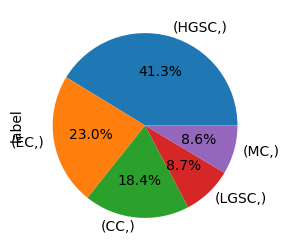

In [4]:
_= df_train[["label"]].value_counts().plot.pie(autopct='%1.1f%%', ylabel="label", figsize=(3,3))
labels = sorted(df_train["label"].unique())
print(f"{labels=}")

## Data for inference

**Note, we canot extract all tiles from all imges because of unsufficient space/storage**

This needs porting several code (classes) form the training notebook:

- extracting the tiles from whole image
- validation argmention, mainly color mean & STD

In [5]:
import os
import pyvips
import numpy as np
import random
from PIL import Image

def extract_image_tiles(
    p_img, folder, size: int = 2048, scale: float = 0.5,
    drop_thr: float = 0.6, white_thr: int = 240, max_samples: int = 50
) -> list:
    name, _ = os.path.splitext(os.path.basename(p_img))
    im = pyvips.Image.new_from_file(p_img)
    w = h = size
    # https://stackoverflow.com/a/47581978/4521646
    idxs = [(y, y + h, x, x + w) for y in range(0, im.height, h) for x in range(0, im.width, w)]
    # random subsample
    max_samples = max_samples if isinstance(max_samples, int) else int(len(idxs) * max_samples)
    random.shuffle(idxs)
    files = []
    for y, y_, x, x_ in idxs:
        # https://libvips.github.io/pyvips/vimage.html#pyvips.Image.crop
        tile = im.crop(x, y, min(w, im.width - x), min(h, im.height - y)).numpy()[..., :3]
        if tile.shape[:2] != (h, w):
            tile_ = tile
            tile_size = (h, w) if tile.ndim == 2 else (h, w, tile.shape[2])
            tile = np.zeros(tile_size, dtype=tile.dtype)
            tile[:tile_.shape[0], :tile_.shape[1], ...] = tile_
        black_bg = np.sum(tile, axis=2) == 0
        tile[black_bg, :] = 255
        mask_bg = np.mean(tile, axis=2) > white_thr
        if np.sum(mask_bg) >= (np.prod(mask_bg.shape) * drop_thr):
            #print(f"skip almost empty tile: {k:06}_{int(x_ / w)}-{int(y_ / h)}")
            continue
        p_img = os.path.join(folder, f"{int(x_ / w)}-{int(y_ / h)}.png")
        # print(tile.shape, tile.dtype, tile.min(), tile.max())
        new_size = int(size * scale), int(size * scale)
        Image.fromarray(tile).resize(new_size, Image.LANCZOS).save(p_img)
        files.append(p_img)
        # need to set counter check as some empty tiles could be skipped earlier
        if len(files) >= max_samples:
            break
    return files, idxs

In [6]:
def extract_prune_tiles(
    path_img: str, folder: str, size: int = 2048, scale: float = 0.25,
    drop_thr: float = 0.6, max_samples: int = 30
) -> str:
    print(f"processing: {path_img}")
    name, _ = os.path.splitext(os.path.basename(path_img))
    folder = os.path.join(folder, name)
    os.makedirs(folder, exist_ok=True)
    tiles, _ = extract_image_tiles(
        path_img, folder, size=size, scale=scale,
        drop_thr=drop_thr, max_samples=max_samples)
    return folder

In [7]:
from torchvision import transforms as T

# img_color_mean = [0.8721593659261734, 0.7799686061900686, 0.8644588534918227]
# img_color_std = [0.08258995918115268, 0.10991684444009092, 0.06839816226731532]

img_color_mean = [0.8552778138171097, 0.7564743080804032, 0.8516484257533921]
img_color_std = [0.08686107152541762, 0.11624014337268014, 0.07164072531619566]

VALID_TRANSFORM = T.Compose([
    T.CenterCrop(512),
    T.ToTensor(),
    #T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    T.Normalize(img_color_mean, img_color_std),  # custom
])

In [8]:
import torch
from PIL import Image
from torch.utils.data import Dataset

class TilesFolderDataset(Dataset):

    def __init__(
        self,
        folder: str,
        image_ext: str =  '.png',
        transforms = None
    ):
        assert os.path.isdir(folder)
        self.transforms = transforms
        self.imgs = glob.glob(os.path.join(folder, "*" + image_ext))

    def __getitem__(self, idx: int) -> tuple:
        img_path = self.imgs[idx]
        assert os.path.isfile(img_path), f"missing: {img_path}"
        img = np.array(Image.open(img_path))[..., :3]
        # filter background
        mask = np.sum(img, axis=2) == 0
        img[mask, :] = 255
        if np.max(img) < 1.5:
            img = np.clip(img * 255, 0, 255).astype(np.uint8)
        # augmentation
        if self.transforms:
            img = self.transforms(Image.fromarray(img))
        #print(f"img dim: {img.shape}")
        return img

    def __len__(self) -> int:
        return len(self.imgs)

found images: 2
processing: /kaggle/input/UBC-OCEAN/test_images/41.png
found tiles: 62


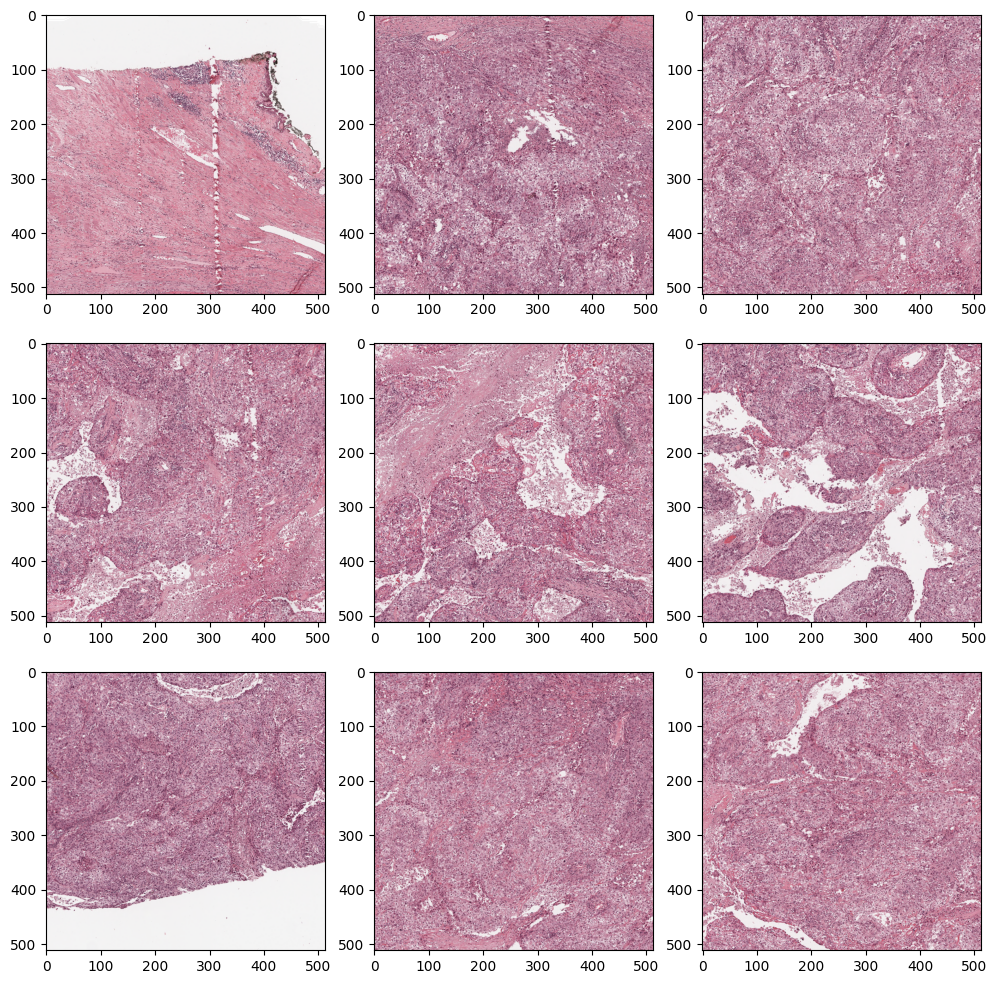

In [11]:
ls = sorted(glob.glob(os.path.join(DATASET_FOLDER, "test_images", '*.png')))
print(f"found images: {len(ls)}")
folder_tiles = extract_prune_tiles(ls[0], IMAGES_FOLDER, size=2048, scale=0.25)
dataset = TilesFolderDataset(folder_tiles)
print(f"found tiles: {len(dataset)}")

# quick view
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
for i in range(9):
    img = dataset[i]
    axes[i // 3, i % 3].imshow(img)
fig.tight_layout()

## CNN Model

We start with some stanrd CNN models taken from torch vision.

In [9]:
import timm
import torch
import torchvision
import pytorch_lightning as pl
from torch import nn
from torch.nn import functional as F


class LitCancerSubtype(pl.LightningModule):

    def __init__(self, net):
        super().__init__()
        self.net = net
        self.arch = net.pretrained_cfg.get('architecture')
        self.num_classes = net.num_classes

    def forward(self, x):
        y = F.softmax(self.net(x))
        if y.isnan().any():
            y = torch.ones(self.num_classes) / self.num_classes
        return y

# ==============================
# ==============================

PATH_CKPT = ("/kaggle/input/ubc-ocean-models/image_classification_model.pt")
ckpt = torch.load(PATH_CKPT, map_location=torch.device('cpu'))

# see: https://pytorch.org/vision/stable/models.html
net = timm.create_model('maxvit_tiny_tf_512', pretrained=False, num_classes=len(labels))
model = LitCancerSubtype(net=net)
model.load_state_dict(ckpt['state_dict'])
print(model)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


LitCancerSubtype(
  (net): MaxxVit(
    (stem): Stem(
      (conv1): Conv2dSame(3, 64, kernel_size=(3, 3), stride=(2, 2))
      (norm1): BatchNormAct2d(
        64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): GELUTanh()
      )
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (stages): Sequential(
      (0): MaxxVitStage(
        (blocks): Sequential(
          (0): MaxxVitBlock(
            (conv): MbConvBlock(
              (shortcut): Downsample2d(
                (pool): AvgPool2dSame(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
                (expand): Identity()
              )
              (pre_norm): BatchNormAct2d(
                64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
                (drop): Identity()
                (act): Identity()
              )
              (down): Identity()
              (conv1_1x1): Conv2d(64, 256, kernel_size=(

## Test data & submission

lest load sample submission and add append images we can predict

In [10]:
df_test = pd.read_csv(os.path.join(DATASET_FOLDER, "test.csv"))
# default label
df_test['label'] = ['HGSC'] * len(df_test)
# labels = list(df_train["label"].unique())
print(f"Dataset/test size: {len(df_test)}")
display(df_test.head())

Dataset/test size: 2


,image_id,image_width,image_height,label
0,41,28469,16987,HGSC
1,66,28469,16987,HGSC


In [14]:
!cat /kaggle/input/UBC-OCEAN/sample_submission.csv

499.72s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


image_id,label
41,HGSC


## Inference

In [12]:
import shutil
from torch.utils.data import DataLoader

model.eval()
model = model.cuda()

submission = []
for _, row in df_test.iterrows():
    row = dict(row)
    # prepare data - cut and load tiles
    folder_tiles = extract_prune_tiles(
        os.path.join(DATASET_FOLDER, "test_images", f"{str(row['image_id'])}.png"),
        IMAGES_FOLDER, size=2048, scale=0.25)
    dataset = TilesFolderDataset(folder_tiles, transforms=VALID_TRANSFORM)
    if not len(dataset):
        print (f"seem no tiles were cut for `{folder_tiles}`")
        submission.append(row)
        continue
    dataloader = DataLoader(dataset, batch_size=4, num_workers=10, shuffle=False)
    # iterate over images and collect predictions
    preds = []
    for imgs in dataloader:
        print(f"{imgs.shape}")
        with torch.no_grad():
            pred = model(imgs.cuda())
        preds += pred.cpu().numpy().tolist()
    print(f"Sum contrinution from all tiles: {np.sum(preds, axis=0)}")
    print(f"Max contribution over all tiles: {np.max(preds, axis=0)}")
    # decide label
    lb = np.argmax(np.sum(preds, axis=0))
    row['label'] = labels[lb]
    print(row)
    submission.append(row)
    # cleaning
    #shutil.rmtree(folder_tiles)
    os.system(f"rm -rf {folder_tiles}")

df_sub = pd.DataFrame(submission)

processing: /kaggle/input/UBC-OCEAN/test_images/41.png


KeyboardInterrupt: 

## Finalize - export submission

In [16]:
display(df_sub.head())
df_sub[["image_id", "label"]].to_csv("/kaggle/working/submission.csv", index=False)

! head submission.csv

,image_id,image_width,image_height,label
0,41,28469,16987,HGSC
1,66,28469,16987,LGSC


690.38s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


head: cannot open 'submission.csv' for reading: No such file or directory
